# Thrivelines for longitudinal change

This notebook shows how to score change between two visits (**z-diff**, **z-gain**) and plot **thrivelines** — expected future z-score trajectories from an age-to-age correlation matrix.

We download a cross-sectional reference dataset (`fcon1000`) and a longitudinal cohort (`LNM_data`), transfer a normative model, load precomputed correlation matrices, score patients, and plot thrivelines.


In [ ]:
%load_ext autoreload
%autoreload 2

import glob
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from pcntoolkit import (
    BLR,
    CorrelationMatrix,
    NormData,
    NormativeModel,
    ZDiffScore,
    ZGainScore,
    load_fcon1000,
    load_lnm,
)
from pcntoolkit.math_functions.basis_function import BsplineBasisFunction
from pcntoolkit.util.plotter import plot_thrivelines

plt.rcParams.update({"figure.max_open_warning": 0})

DATA_DIR = Path("pcntoolkit_resources") / "data"
N_REGIONS = 10
CENTILES = [0.05, 0.25, 0.5, 0.75, 0.95]
Z_ANCHORS = stats.norm.ppf(CENTILES)
COVARIATE = "age"


In [ ]:
def tidy_region_names(df: pd.DataFrame) -> pd.DataFrame:
    """Align fcon and LNM cortical-thickness column names."""
    metadata = {"sub_id", "age", "sex", "site", "visit", "group"}
    return df.rename(
        columns={
            column: column.replace("&", "_and_").replace("_thickness", "")
            for column in df.columns
            if column not in metadata
        }
    )


def region_from_velocity_folder(folder_name: str) -> str:
    return re.sub(r"^batch_\d+_", "", folder_name)


def list_velocity_matrices(n_regions: int = N_REGIONS) -> list[tuple[str, str]]:
    """Return up to ``n_regions`` (folder_name, pickle_path) pairs."""
    base_dir = None
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        folder = candidate / "pcntoolkit_resources" / "velocity"
        if folder.is_dir():
            base_dir = folder
            break
    if base_dir is None:
        return []

    region_pkls: dict[str, str] = {}
    for folder_path in sorted(base_dir.iterdir()):
        if not folder_path.is_dir():
            continue
        pkl_list = sorted(glob.glob(str(folder_path / "**" / "*.pkl"), recursive=True))
        if not pkl_list:
            continue
        velocity_pkls = [
            path for path in pkl_list if "velocity" in os.path.basename(path).lower()
        ]
        region_pkls[folder_path.name] = velocity_pkls[0] if velocity_pkls else pkl_list[0]

    return sorted(region_pkls.items())[:n_regions]


## 1. Download data

`load_fcon1000()` and `load_lnm()` download example CSVs (or reuse cached copies). We tidy region column names here so fcon and LNM line up.

In [ ]:
# Cache CSVs via the loaders, then read and tidy column names in the notebook.
load_fcon1000()
load_lnm()

reference_df = tidy_region_names(pd.read_csv(DATA_DIR / "fcon1000.csv"))
lnm_df = tidy_region_names(pd.read_csv(DATA_DIR / "LNM_data.csv"))

velocity_mats = list_velocity_matrices()
if velocity_mats:
    response_vars = [
        region_from_velocity_folder(folder)
        for folder, _ in velocity_mats
        if region_from_velocity_folder(folder) in reference_df.columns
    ][:N_REGIONS]

if not velocity_mats or len(response_vars) < 2:
    response_vars = ["rh_S_front_sup", "rh_G_front_middle"]

print("Response vars:", response_vars)
print("Velocity matrices found:", len(velocity_mats))


## 2. Fit and transfer the normative model

Fit on cross-sectional fcon1000 data, transfer to the LNM controls, then predict z-scores.

In [ ]:
reference_data = NormData.from_dataframe(
    name="reference",
    dataframe=reference_df,
    covariates=["age"],
    batch_effects=["site", "sex"],
    response_vars=response_vars,
    subject_ids="sub_id",
)

fcon1000_model = NormativeModel(
    BLR(
        basis_function_mean=BsplineBasisFunction(degree=3, nknots=5),
        warp_name="warpsinharcsinh",
    ),
    inscaler="standardize",
    outscaler="standardize",
    savemodel=False,
    saveresults=False,
)

fcon1000_model.fit(reference_data)
print("Reference model fitted")


In [ ]:
control_df = lnm_df[lnm_df["group"] == "control"]
patient_df = lnm_df[lnm_df["group"] == "patient"]

control_data = NormData.from_dataframe(
    name="control",
    dataframe=control_df,
    covariates=["age"],
    batch_effects=["site", "sex"],
    response_vars=response_vars,
    subject_ids="sub_id",
    visits="visit",
)

patient_data = NormData.from_dataframe(
    name="patient",
    dataframe=patient_df,
    covariates=["age"],
    batch_effects=["site", "sex"],
    response_vars=response_vars,
    subject_ids="sub_id",
    visits="visit",
)

control_adapt, control_test = control_data.train_test_split(splits=[0.2, 0.8])
lnm_model = fcon1000_model.transfer(control_adapt)
lnm_model.predict(control_test)
lnm_model.predict(patient_data)

print("Control subjects:", control_df["sub_id"].nunique())
print("Patient subjects:", patient_df["sub_id"].nunique())


### Visualize the longitudinal dataset

Each subject has two visits. One line per subject connects the two timepoints.

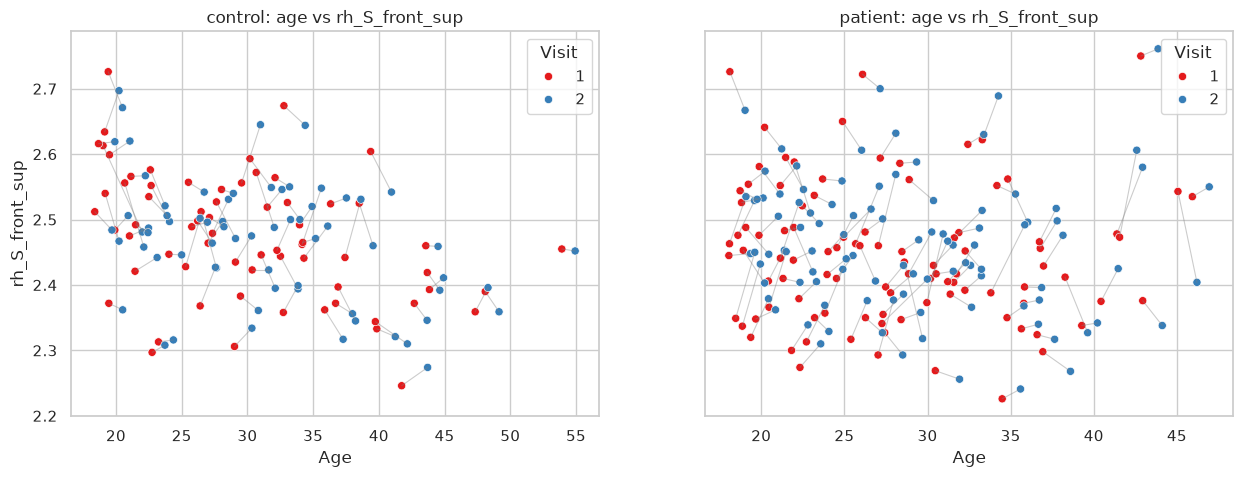

In [ ]:
def _longitudinal_plot_frame(data: NormData, feature: str) -> pd.DataFrame:
    wide = data.to_dataframe()
    return pd.DataFrame(
        {
            "sub_id": wide[("subject_ids", "subject_ids")].values,
            "age": wide[("X", "age")].values,
            "visit": wide[("visits", "visit")].values,
            feature: wide[("Y", feature)].values,
        }
    )


feature_to_plot = response_vars[0]
groups = {
    "control": _longitudinal_plot_frame(control_data, feature_to_plot),
    "patient": _longitudinal_plot_frame(patient_data, feature_to_plot),
}

fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for axis, (group_name, group_df) in zip(ax, groups.items()):
    for _, subject_rows in group_df.groupby("sub_id"):
        ordered = subject_rows.sort_values("visit")
        axis.plot(
            ordered["age"],
            ordered[feature_to_plot],
            color="grey",
            alpha=0.4,
            lw=0.8,
        )
    sns.scatterplot(
        data=group_df,
        x="age",
        y=feature_to_plot,
        hue="visit",
        palette="Set1",
        s=35,
        ax=axis,
    )
    axis.legend(title="Visit")
    axis.set_title(f"{group_name}: age vs {feature_to_plot}")
    axis.set_xlabel("Age")
    axis.set_ylabel(feature_to_plot)
plt.show()


## 3. Load precomputed correlation matrices

z-gain and thrivelines need an age-to-age correlation matrix. Place Johanna Bayer-style velocity pickles under `pcntoolkit_resources/velocity/` (`batch_<n>_<region>/Velocity/*.pkl`) and load them with `CorrelationMatrix.load()`. If none are found locally, we estimate one matrix from the control test split.

In [ ]:
region = response_vars[0]
matrix_path = None
if velocity_mats:
    for folder_name, path in velocity_mats:
        if region_from_velocity_folder(folder_name) == region:
            matrix_path = path
            break

if matrix_path is not None:
    corr = CorrelationMatrix.load(matrix_path)
    print("Loaded matrix:", matrix_path)
else:
    print(
        "No saved matrix for the demo region — estimating from control_test "
        "so the tutorial runs locally."
    )
    corr = CorrelationMatrix.compute(control_test, bandwidth=3, covariate=COVARIATE)

print("bandwidth:", corr.bandwidth)
print("n_subjects:", corr.n_subjects)
print("estimated_range:", corr.estimated_range)


## 4. z-diff and z-gain

Score subject-level change between visits. z-diff is a direct z-score difference; z-gain uses the correlation matrix.

In [ ]:
zdiff = ZDiffScore(
    normative_model=lnm_model,
    reference_data=control_test,
    subject_id_col="sub_id",
)
zdiff_scores = zdiff.score(score_data=patient_data, subject_id_col="sub_id")

zgain = ZGainScore(lnm_model, corr)
zgain_scores = zgain.score(score_data=patient_data)

print(zdiff_scores.to_dataframe(name="z_diff").unstack("response_vars").head())
print(zgain_scores.to_dataframe(name="z_gain").unstack("response_vars").head())


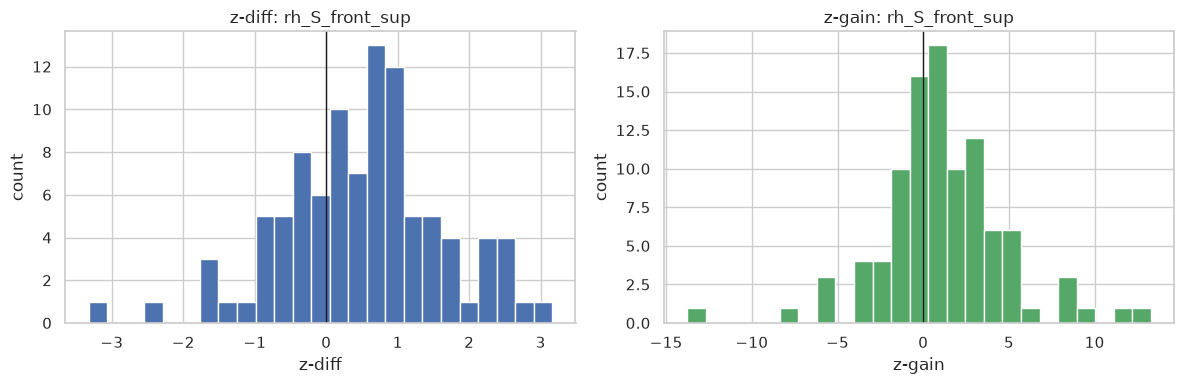

In [60]:
zd = zdiff_scores.sel(response_vars=region).values
zg = zgain_scores.sel(response_vars=region).values

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(zd, bins=25, color="#4c72b0", edgecolor="white")
ax[0].axvline(0, color="k", lw=1)
ax[0].set_xlabel("z-diff")
ax[0].set_ylabel("count")
ax[0].set_title(f"z-diff: {region}")

ax[1].hist(zg, bins=25, color="#55a868", edgecolor="white")
ax[1].axvline(0, color="k", lw=1)
ax[1].set_xlabel("z-gain")
ax[1].set_ylabel("count")
ax[1].set_title(f"z-gain: {region}")
plt.tight_layout()
plt.show()


## 5. Thrivelines and centile plots

The **thriveline table** comes from the correlation matrix (`ZGainScore.get_thrivelines`). It lives in **z-space**: each segment tells you how a z-score is expected to change across ages.

`plot_thrivelines` overlays those segments on **centile curves**. The **normative model** you pass in does two jobs:

1. **Centiles** — it maps covariate values to the reference distribution in **y-space** (raw thickness).
2. **Thriveline y-coordinates** — it converts the z-space thriveline segments back to **y-space** so they sit on the same axis as the centiles.

So: correlation matrix → thriveline *shape* in z-space; normative model → centiles and the y-axis mapping for both.

In [ ]:
age_lo = int(np.ceil(lnm_model.covariate_ranges[COVARIATE]["min"]))
age_hi = int(np.floor(lnm_model.covariate_ranges[COVARIATE]["max"]))

all_thrivelines: list[pd.DataFrame] = []
for folder_name, pkl_path in velocity_mats:
    region_name = region_from_velocity_folder(folder_name)
    if region_name not in lnm_model.response_vars:
        continue

    corr_region = CorrelationMatrix.load(pkl_path)
    zgain_region = ZGainScore(lnm_model, corr_region)
    region_tl = zgain_region.get_thrivelines(
        z_anchors=Z_ANCHORS,
        covariate_range=(age_lo, age_hi),
    )
    region_tl["region_name"] = folder_name
    all_thrivelines.append(region_tl)
    print(folder_name, "→", region_name, f"({len(region_tl)} rows)")

if not all_thrivelines:
    region_tl = zgain.get_thrivelines(
        z_anchors=Z_ANCHORS,
        covariate_range=(age_lo, age_hi),
    )
    region_tl["region_name"] = region
    all_thrivelines = [region_tl]

selected_thrivelines = all_thrivelines[:N_REGIONS]
print("Plotting", len(selected_thrivelines), "regions")


In [ ]:
for region_tl in selected_thrivelines:
    plot_region = str(region_tl["response_var"].dropna().iloc[0])
    plot_thrivelines(
        lnm_model,
        thrivelines=region_tl,
        centiles=CENTILES,
        covariate=COVARIATE,
        response_vars=[plot_region],
        show_figure=True,
        show_centile_labels=True,
    )


## Appendix: compute your own correlation matrix

When you have enough longitudinal controls at multiple ages, estimate the matrix with `CorrelationMatrix.compute()` instead of loading a shared file.

In [ ]:
corr_demo = CorrelationMatrix.compute(
    control_test,
    bandwidth=3,
    covariate=COVARIATE,
)

print("bandwidth:", corr_demo.bandwidth)
print("n_subjects:", corr_demo.n_subjects)
print("estimated_range:", corr_demo.estimated_range)


In [ ]:
R = corr_demo.matrix.sel(response_vars=region)
age_lo, age_hi = 18, 50
R = R.sel(age_1=slice(age_lo, age_hi), age_2=slice(age_lo, age_hi))

plt.figure(figsize=(5, 4))
plt.imshow(R.values[0], aspect="auto", origin="lower", cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="correlation")
plt.xlabel("age (visit 2)")
plt.ylabel("age (visit 1)")
plt.title(f"Age-to-age correlations — {region}")
plt.show()
